# 10. Bootstrap Significance Testing (Ablation Study)

## 0. Setup

In [20]:
import csv
import random
import re
import json
import math
import traceback
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt

MANIFEST = Path('~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv').expanduser()
ROOT     = Path('~/Desktop/Thesis/TR-6').expanduser()
GAS_NORM = Path('~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json').expanduser()
RUNS     = Path('~/Desktop/convscript/runs').expanduser()

DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f'Device: {DEVICE}')

ABLATION_OUT = RUNS / "05_ablation_study"
BOOT_OUT = RUNS / "10_bootstrap_significance"
BOOT_OUT.mkdir(parents=True, exist_ok=True)

FAILURES = []
THRESHOLDS_TO_SWEEP = [t / 100 for t in range(10, 91)]


Device: mps


## Data pipeline

In [21]:
FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}
SESSION_TO_IDX = {'morning': 0, 'afternoon': 1, 'evening': 2}
LABEL_TO_IDX   = {'not_spoiled': 0, 'spoiled': 1}
IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
SESSION_HOUR_BUCKETS = {'morning': (5, 11), 'afternoon': (12, 16), 'evening': (16, 19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)


def safe_float(val, default=0.0):
    try:
        return float(val)
    except Exception:
        return default


def hour_to_session(hour):
    for name, (lo, hi) in SESSION_HOUR_BUCKETS.items():
        if lo <= hour < hi:
            return name
    return 'unknown'


def find_ir_folder(base):
    for name in ['IR_fusion_images', 'IR_Fusion_images', 'ir_fusion_images']:
        p = base / name
        if p.exists():
            return p
    return base / 'IR_fusion_images'


def group_images_by_session(folder, pattern):
    result = defaultdict(lambda: defaultdict(list))
    if not folder.exists():
        return {}
    for f in sorted(folder.iterdir()):
        m = pattern.search(f.name)
        if not m:
            continue
        session = hour_to_session(int(m.group(2)[:2]))
        if session != 'unknown':
            result[m.group(1)][session].append(f)
    return dict(result)


def load_image(path, transform):
    return transform(Image.open(path).convert('RGB'))


def get_rgb_transform(train: bool):
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def get_ir_transform(train: bool):
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


In [22]:
class TrimodalDataset(Dataset):
    def __init__(self, manifest_path, root, train=True, modality_dropout_prob=0.0,
                 exclude_flagged=True, split=None, gas_norm_stats_path=None,
                 cache_images=True, shared_pixel_cache=None):
        self.root = Path(root); self.train = train
        self.rgb_transform = get_rgb_transform(train); self.ir_transform = get_ir_transform(train)
        self.gas_norm_stats = None
        if gas_norm_stats_path:
            with open(gas_norm_stats_path) as f:
                self.gas_norm_stats = json.load(f)['stats']
        with open(manifest_path, newline='') as f:
            all_rows = list(csv.DictReader(f))
        if exclude_flagged:
            all_rows = [r for r in all_rows if r.get('exclude', '').strip().lower() != 'true']
        if split:
            all_rows = [r for r in all_rows if r.get('split', '').strip().lower() == split.lower()]
        self.samples = []; self._build_samples(all_rows)
        self._image_cache = {}; self._build_image_index()
        self._pixel_cache = {}
        if shared_pixel_cache is not None:
            self._pixel_cache = shared_pixel_cache
        elif cache_images:
            self._warmup_pixel_cache()
        print(f'TrimodalDataset: {len(self.samples)} sessions (split={split})')

    def _build_samples(self, rows):
        for row in rows:
            fruit = row['fruit']; label = row['label']; date_str = row['actual_date']
            global_day = int(row['corrected_day_index'])
            days_until = safe_float(row.get('days_until_spoilage', ''), default=-1.0)
            for session in ['morning', 'afternoon', 'evening']:
                si = SESSION_TO_IDX[session]
                ir_avail = safe_float(row.get(f'ir_{session}_count', 0)) > 0
                ir_tmin = safe_float(row.get(f'ir_{session}_tmin', ''), 0.0)
                ir_tmax = safe_float(row.get(f'ir_{session}_tmax', ''), 0.0)
                ir_trange = safe_float(row.get(f'ir_{session}_trange', ''), 0.0)
                srgb_avail = safe_float(row.get(f'srgb_{session}_count', 0)) > 0
                gas_avail = row.get(f'methane_{session}_present', '').strip().upper() == 'TRUE'
                mean_ppm = safe_float(row.get(f'methane_{session}_ppm', ''), 0.0)
                std_ppm = safe_float(row.get(f'methane_{session}_std', ''), 0.0)
                left_ppm = safe_float(row.get(f'methane_{session}_left', ''), 0.0)
                right_ppm = safe_float(row.get(f'methane_{session}_right', ''), 0.0)
                if not ir_avail and not srgb_avail and not gas_avail:
                    continue
                self.samples.append({'fruit': fruit, 'label': label, 'actual_date': date_str,
                    'corrected_day_index': global_day, 'session': session, 'session_idx': si,
                    'fruit_idx': FRUIT_TO_IDX.get(fruit, 0), 'label_idx': LABEL_TO_IDX.get(label, 0),
                    'days_until_spoilage': days_until, 'ir_tmin': ir_tmin, 'ir_tmax': ir_tmax,
                    'ir_trange': ir_trange, 'gas_mean': mean_ppm, 'gas_std': std_ppm,
                    'gas_left': left_ppm, 'gas_right': right_ppm, 'gas_asym': abs(left_ppm - right_ppm),
                    'rgb_available': srgb_avail, 'ir_available': ir_avail, 'gas_available': gas_avail})

    def _build_image_index(self):
        label_map = {'not_spoiled': 'Not_spoiled', 'spoiled': 'Spoiled'}
        for fruit in FRUIT_LIST:
            for lk, lf in label_map.items():
                base = self.root / 'Classified' / fruit / lf
                for d, ss in group_images_by_session(base / 'sRGB_images', SRGB_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['rgb'] = ps
                for d, ss in group_images_by_session(find_ir_folder(base), IR_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['ir'] = ps
        banana_ir = group_images_by_session(find_ir_folder(self.root / 'Normal' / 'Banana'), IR_PATTERN)
        spoiled_dates = {date for (fr, lb, date, _) in self._image_cache if fr == 'Banana' and lb == 'spoiled'}
        for d, ss in banana_ir.items():
            if d in spoiled_dates:
                for s, ps in ss.items():
                    key = ('Banana', 'spoiled', d, s)
                    self._image_cache.setdefault(key, {'rgb': [], 'ir': []})
                    if not self._image_cache[key].get('ir'):
                        self._image_cache[key]['ir'] = ps

    def _load_cached(self, path, transform):
        cached = self._pixel_cache.get(str(path))
        if cached is not None:
            return transform(Image.fromarray(cached.permute(1, 2, 0).numpy()))
        return load_image(path, transform)

    def _warmup_pixel_cache(self):
        all_paths = set()
        for v in self._image_cache.values():
            all_paths.update(v.get('rgb', [])); all_paths.update(v.get('ir', []))
        for path in all_paths:
            try:
                img = self.rgb_transform.transforms[0](Image.open(path).convert('RGB'))
                self._pixel_cache[str(path)] = torch.from_numpy(np.array(img)).permute(2, 0, 1)
            except Exception:
                pass

    def _normalize_gas(self, fruit, session, mean_ppm, std_ppm, left_ppm, right_ppm):
        if self.gas_norm_stats is None:
            return mean_ppm, std_ppm, left_ppm, right_ppm
        s = self.gas_norm_stats.get(fruit, {}).get(session, {})

        def norm(val, key):
            st = s.get(key, {'mean': 0., 'std': 1.})
            return (val - st['mean']) / st['std']
        return norm(mean_ppm, 'mean_ppm'), norm(std_ppm, 'std_ppm'), norm(left_ppm, 'left_ppm'), norm(right_ppm, 'right_ppm')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        fruit = s['fruit']; label = s['label']; date_str = s['actual_date']
        session = s['session']; si = s['session_idx']
        rgb_avail, ir_avail, gas_avail = s['rgb_available'], s['ir_available'], s['gas_available']
        cached = self._image_cache.get((fruit, label, date_str, session), {'rgb': [], 'ir': []})
        if rgb_avail and cached['rgb']:
            rgb_tensors = torch.stack([self._load_cached(p, self.rgb_transform) for p in cached['rgb']])
        else:
            rgb_avail = False; rgb_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        if ir_avail and cached['ir']:
            ir_tensors = torch.stack([self._load_cached(p, self.ir_transform) for p in cached['ir']])
        else:
            ir_avail = False; ir_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        if gas_avail:
            m, sd, l, r = self._normalize_gas(fruit, session, s['gas_mean'], s['gas_std'], s['gas_left'], s['gas_right'])
            gas = torch.tensor([m, sd, l, r, abs(l - r), float(si) / 2.], dtype=torch.float32)
        else:
            gas = torch.zeros(6)
        return {'rgb_images': rgb_tensors, 'ir_images': ir_tensors, 'gas': gas,
                'rgb_available': torch.tensor(rgb_avail, dtype=torch.bool),
                'ir_available': torch.tensor(ir_avail, dtype=torch.bool),
                'gas_available': torch.tensor(gas_avail, dtype=torch.bool),
                'fruit_idx': torch.tensor(s['fruit_idx'], dtype=torch.long),
                'session_idx': torch.tensor(si, dtype=torch.long),
                'label': torch.tensor(s['label_idx'], dtype=torch.long),
                'days_until_spoilage': torch.tensor(s['days_until_spoilage'], dtype=torch.float32),
                'fruit': fruit, 'actual_date': date_str, 'corrected_day_index': s['corrected_day_index']}


class DayLevelSequenceDataset(Dataset):
    def __init__(self, manifest_path=MANIFEST, root=ROOT, split="train",
                 gas_norm_stats_path=GAS_NORM, shared_pixel_cache=None):
        base = TrimodalDataset(manifest_path, root, train=False, split=split,
                                gas_norm_stats_path=gas_norm_stats_path, cache_images=True,
                                shared_pixel_cache=shared_pixel_cache)
        self._pixel_cache = base._pixel_cache
        day_groups = defaultdict(list)
        for i in range(len(base)):
            item = base[i]
            key = (item["fruit"], int(item["label"].item()), int(item["corrected_day_index"]))
            day_groups[key].append(item)
        day_entries = {}
        for (fruit, label, day_idx), sessions in day_groups.items():
            sessions.sort(key=lambda s: int(s["session_idx"].item()))
            rgb_img, ir_img = None, None
            for s in sessions:
                if rgb_img is None and bool(s["rgb_available"].item()) and len(s["rgb_images"]) > 0:
                    rgb_img = s["rgb_images"][0]
                if ir_img is None and bool(s["ir_available"].item()) and len(s["ir_images"]) > 0:
                    ir_img = s["ir_images"][0]
            gas_vals = [s["gas"] for s in sessions if bool(s["gas_available"].item())]
            gas_avail = len(gas_vals) > 0
            gas_vec = torch.stack(gas_vals).mean(dim=0) if gas_avail else torch.zeros(6)
            day_entries.setdefault((fruit, label), []).append({
                "day_idx": day_idx, "rgb_img": rgb_img, "ir_img": ir_img,
                "gas_vec": gas_vec, "gas_avail": gas_avail,
                "fruit_idx": sessions[0]["fruit_idx"], "label": sessions[0]["label"],
            })
        self.trajectories = []
        for (fruit, label), days in day_entries.items():
            days.sort(key=lambda d: d["day_idx"])
            last_observed_idx = None
            for d in days:
                d["delta"] = 0.0 if last_observed_idx is None else float(d["day_idx"] - last_observed_idx)
                if d["gas_avail"]:
                    last_observed_idx = d["day_idx"]
            self.trajectories.append({"fruit": fruit, "label": label, "days": days})
        print(f"  DayLevelSequenceDataset: {len(self.trajectories)} trajectories (split={split})")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq = torch.stack([d["ir_img"] if d["ir_img"] is not None else blank_ir for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail = torch.tensor([d["ir_img"] is not None for d in traj], dtype=torch.bool)
        gas_seq = torch.stack([d["gas_vec"] for d in traj])
        gas_mask = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {"rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
                "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
                "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"]}


def day_sequence_collate(batch):
    max_T = max(b["T"] for b in batch)
    B = len(batch)
    rgb = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    ir = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    rgb_avail = torch.zeros(B, max_T, dtype=torch.bool)
    ir_avail = torch.zeros(B, max_T, dtype=torch.bool)
    gas = torch.zeros(B, max_T, 6)
    gas_mask = torch.zeros(B, max_T)
    gas_delta = torch.zeros(B, max_T)
    pad_mask = torch.ones(B, max_T, dtype=torch.bool)
    fruit_idx = torch.zeros(B, dtype=torch.long)
    label = torch.zeros(B, dtype=torch.long)
    for i, b in enumerate(batch):
        T = b["T"]
        rgb[i, :T] = b["rgb_seq"]; ir[i, :T] = b["ir_seq"]
        rgb_avail[i, :T] = b["rgb_avail"]; ir_avail[i, :T] = b["ir_avail"]
        gas[i, :T] = b["gas_seq"]; gas_mask[i, :T] = b["gas_mask"]; gas_delta[i, :T] = b["gas_delta"]
        pad_mask[i, :T] = False
        fruit_idx[i] = b["fruit_idx"]; label[i] = b["label"]
    return {"rgb_seq": rgb, "ir_seq": ir, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas, "gas_mask": gas_mask, "gas_delta": gas_delta, "pad_mask": pad_mask,
            "fruit_idx": fruit_idx, "label": label}


## Model classes

In [23]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, channels, 1, bias=False))

    def forward(self, x):
        return torch.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = x * self.channel_attn(x)
        sa = self.spatial_attn(x)
        return x * sa, sa


BACKBONE_FEATURE_DIMS = {"efficientnet_b0": 1280}


def _infer_feature_dim(backbone, img_size=IMAGE_SIZE):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, img_size, img_size)
        out = backbone(dummy)
    return out.shape[1]


def build_cnn_backbone(name: str):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        return base.features, BACKBONE_FEATURE_DIMS[name]
    elif name == "convnext_tiny":
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        backbone = base.features
        feat_dim = _infer_feature_dim(backbone)
        BACKBONE_FEATURE_DIMS[name] = feat_dim
        return backbone, feat_dim
    else:
        raise ValueError(f"Unknown backbone: {name}")


class VisualEncoderToggle(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", freeze_backbone=True,
                 use_cbam=True, chunk_size=8):
        super().__init__()
        self.use_cbam = use_cbam
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        self.chunk_size = chunk_size
        if use_cbam:
            self.cbam = CBAM(self.feature_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, seq: torch.Tensor):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        feats_list = []
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            feat_map = checkpoint(self.backbone, chunk, use_reentrant=False) if needs_ckpt else self.backbone(chunk)
            if self.use_cbam:
                feat_map, _ = self.cbam(feat_map)
            feats_list.append(self.pool(feat_map).flatten(1))
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)
        return feats


class GRUDCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, x_mean=None):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        if x_mean is None:
            x_mean = [0.0] * input_dim
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))
        self.W_gamma_x = nn.Linear(1, input_dim)
        self.W_gamma_h = nn.Linear(1, hidden_dim)
        self.gru_cell = nn.GRUCell(input_dim * 2, hidden_dim)

    def forward(self, x_t, m_t, delta_t, x_last, h_prev):
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(delta_t), min=0.0))
        x_bar = self.x_mean.unsqueeze(0).expand_as(x_t)
        x_hat = m_t * x_t + (1 - m_t) * (gamma_x * x_last + (1 - gamma_x) * x_bar)
        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(delta_t), min=0.0))
        h_t = self.gru_cell(torch.cat([x_hat, m_t], dim=-1), gamma_h * h_prev)
        return h_t, x_hat


class GasGRUDSequenceEncoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, x_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = GRUDCell(input_dim, hidden_dim, x_mean)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        B, T, D = gas_seq.shape
        device = gas_seq.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        x_last = torch.zeros(B, D, device=device)
        h_seq = []
        for t in range(T):
            x_t = gas_seq[:, t]
            m_t = gas_mask[:, t].unsqueeze(-1).expand(-1, D)
            delta_t = gas_delta[:, t].unsqueeze(-1)
            valid_t = (~pad_mask[:, t]).float().unsqueeze(-1)
            h_new, x_hat = self.cell(x_t, m_t, delta_t, x_last, h)
            h = valid_t * h_new + (1 - valid_t) * h
            x_last = torch.where(m_t.bool(), x_t, x_last)
            h_seq.append(h)
        return torch.stack(h_seq, dim=1)


class GasEncoderMeanImpute(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gru = nn.GRU(input_dim + 1, hidden_dim, batch_first=True)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        imputed = gas_seq * gas_mask.unsqueeze(-1)
        gru_input = torch.cat([imputed, gas_mask.unsqueeze(-1)], dim=-1)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(gru_input, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=gas_seq.shape[1])
        return out


class FusionToggle(nn.Module):
    def __init__(self, d_model=64, num_heads=4, dropout=0.1, use_cross_attn=True):
        super().__init__()
        self.use_cross_attn = use_cross_attn
        if use_cross_attn:
            self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                               dropout=dropout, batch_first=True)
            self.norm = nn.LayerNorm(d_model)
        else:
            self.concat_proj = nn.Sequential(
                nn.Linear(d_model * 3, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout),
            )

    def forward(self, rgb_t, ir_t, gas_t, rgb_avail_t, ir_avail_t, gas_avail_t):
        if self.use_cross_attn:
            tokens = torch.stack([rgb_t, ir_t, gas_t], dim=1)
            avail = torch.stack([rgb_avail_t, ir_avail_t, gas_avail_t], dim=1)
            key_padding_mask = ~avail
            fully_missing = key_padding_mask.all(dim=1)
            if fully_missing.any():
                key_padding_mask = key_padding_mask.clone()
                key_padding_mask[fully_missing] = False
            attended, attn_w = self.attn(tokens, tokens, tokens, key_padding_mask=key_padding_mask,
                                          need_weights=True, average_attn_weights=True)
            out = self.norm(tokens + attended)
            return out.mean(dim=1), attn_w
        else:
            concat = torch.cat([rgb_t, ir_t, gas_t], dim=-1)
            return self.concat_proj(concat), None


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.shape[1]]


class TemporalTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dim_feedforward=512,
                 dropout=0.1, max_len=100):
        super().__init__()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        z_seq = self.pos_enc(z_seq)
        return self.encoder(z_seq, src_key_padding_mask=pad_mask)


class LSTMTemporalModule(nn.Module):
    def __init__(self, d_model=64, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(d_model, hidden_dim, num_layers=num_layers, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.out_proj = nn.Linear(hidden_dim, d_model) if hidden_dim != d_model else nn.Identity()

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(z_seq, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=z_seq.shape[1])
        return self.out_proj(out)


def gather_last_valid(H: torch.Tensor, pad_mask: torch.Tensor):
    device = H.device
    lengths = (~pad_mask).sum(dim=1)
    last_idx = (lengths - 1).clamp(min=0)
    B = H.shape[0]
    return H[torch.arange(B, device=device), last_idx], last_idx


ABLATION_CONFIGS = {
    "baseline_a_early": {"fusion_type": "early", "use_cbam": False, "use_cross_attn": False,
                          "temporal_type": "lstm", "missing_handling": "mean"},
    "baseline_b_late": {"fusion_type": "late", "use_cbam": False, "use_cross_attn": False,
                         "temporal_type": "lstm", "missing_handling": "mean"},
    "ablation_1_no_cbam": {"fusion_type": "intermediate", "use_cbam": False, "use_cross_attn": True,
                            "temporal_type": "transformer", "missing_handling": "grud"},
    "ablation_2_no_cross_attn": {"fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": False,
                                  "temporal_type": "transformer", "missing_handling": "grud"},
    "ablation_3_lstm_not_transformer": {"fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
                                         "temporal_type": "lstm", "missing_handling": "grud"},
    "ablation_4_mean_impute_not_grud": {"fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
                                         "temporal_type": "transformer", "missing_handling": "mean"},
    "full_model": {"fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
                   "temporal_type": "transformer", "missing_handling": "grud"},
}
CONFIG_ORDER = ["full_model", "ablation_1_no_cbam", "ablation_2_no_cross_attn",
                "ablation_3_lstm_not_transformer", "ablation_4_mean_impute_not_grud",
                "baseline_a_early", "baseline_b_late"]
CONFIG_LABELS = {
    "full_model": "Full Model", "ablation_1_no_cbam": "Ablation 1 (no CBAM)",
    "ablation_2_no_cross_attn": "Ablation 2 (no cross-attn)",
    "ablation_3_lstm_not_transformer": "Ablation 3 (LSTM)",
    "ablation_4_mean_impute_not_grud": "Ablation 4 (mean-impute)",
    "baseline_a_early": "Baseline A (early fusion)", "baseline_b_late": "Baseline B (late fusion)",
}


In [24]:
class AblationModel(nn.Module):
    def __init__(self, config: dict, d_model=64, backbone_name="efficientnet_b0", gas_hidden=64,
                 num_heads=4, temporal_layers=2, dropout=0.5, cls_dropout=0.5,
                 freeze_visual_backbone=True):
        super().__init__()
        self.config = config
        self.d_model = d_model
        self.fusion_type = config["fusion_type"]

        self.rgb_encoder = VisualEncoderToggle(backbone_name, freeze_visual_backbone, use_cbam=config["use_cbam"])
        self.ir_encoder = VisualEncoderToggle(backbone_name, freeze_visual_backbone, use_cbam=config["use_cbam"])
        if config["missing_handling"] == "grud":
            self.gas_encoder = GasGRUDSequenceEncoder(input_dim=6, hidden_dim=gas_hidden)
        else:
            self.gas_encoder = GasEncoderMeanImpute(input_dim=6, hidden_dim=gas_hidden)

        self.rgb_proj = nn.Sequential(nn.Linear(self.rgb_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.ir_proj = nn.Sequential(nn.Linear(self.ir_encoder.feature_dim, d_model),
                                      nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.gas_proj = nn.Sequential(nn.Linear(gas_hidden, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))

        def make_temporal():
            if config["temporal_type"] == "transformer":
                return TemporalTransformer(d_model=d_model, nhead=num_heads,
                                            num_layers=temporal_layers, dropout=dropout)
            return LSTMTemporalModule(d_model=d_model, hidden_dim=d_model, dropout=dropout)

        def make_heads():
            cls = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout), nn.Linear(128, 2))
            reg = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout),
                                 nn.Linear(128, 1), nn.ReLU())
            return cls, reg

        if self.fusion_type == "intermediate":
            self.fusion = FusionToggle(d_model=d_model, num_heads=num_heads, dropout=dropout,
                                        use_cross_attn=config["use_cross_attn"])
            self.temporal = make_temporal()
            self.cls_head, self.reg_head = make_heads()
        elif self.fusion_type == "early":
            self.early_proj = nn.Sequential(nn.Linear(d_model * 3, d_model),
                                             nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
            self.temporal = make_temporal()
            self.cls_head, self.reg_head = make_heads()
        elif self.fusion_type == "late":
            self.temporal_rgb = make_temporal(); self.temporal_ir = make_temporal(); self.temporal_gas = make_temporal()
            self.cls_head_rgb, self.reg_head_rgb = make_heads()
            self.cls_head_ir, self.reg_head_ir = make_heads()
            self.cls_head_gas, self.reg_head_gas = make_heads()
        else:
            raise ValueError(f"Unknown fusion_type: {self.fusion_type}")
        self.gas_recon_head = nn.Sequential(nn.Linear(d_model * 2, 128), nn.ReLU(),
                                             nn.Dropout(cls_dropout), nn.Linear(128, 6))

    def forward(self, batch: dict):
        device = next(self.parameters()).device
        rgb_seq = batch["rgb_seq"].to(device); ir_seq = batch["ir_seq"].to(device)
        rgb_avail = batch["rgb_avail"].to(device); ir_avail = batch["ir_avail"].to(device)
        gas_seq = batch["gas_seq"].to(device); gas_mask = batch["gas_mask"].to(device)
        gas_delta = batch["gas_delta"].to(device); pad_mask = batch["pad_mask"].to(device)
        B, T = rgb_avail.shape

        rgb_feat = self.rgb_encoder(rgb_seq)
        ir_feat = self.ir_encoder(ir_seq)
        gas_feat = self.gas_encoder(gas_seq, gas_mask, gas_delta, pad_mask)

        rgb_proj = self.rgb_proj(rgb_feat) * rgb_avail.unsqueeze(-1).float()
        ir_proj = self.ir_proj(ir_feat) * ir_avail.unsqueeze(-1).float()
        gas_proj = self.gas_proj(gas_feat) * gas_mask.unsqueeze(-1)

        if self.fusion_type == "intermediate":
            rgb_flat = rgb_proj.reshape(B * T, -1); ir_flat = ir_proj.reshape(B * T, -1); gas_flat = gas_proj.reshape(B * T, -1)
            rgb_av_flat = rgb_avail.reshape(B * T); ir_av_flat = ir_avail.reshape(B * T); gas_av_flat = gas_mask.reshape(B * T).bool()
            z_flat, _ = self.fusion(rgb_flat, ir_flat, gas_flat, rgb_av_flat, ir_av_flat, gas_av_flat)
            z_seq = z_flat.reshape(B, T, -1)
            H = self.temporal(z_seq, pad_mask)
            H_T, last_idx = gather_last_valid(H, pad_mask)
            cls_logits = self.cls_head(H_T); reg_output = self.reg_head(H_T)
        elif self.fusion_type == "early":
            z_seq = self.early_proj(torch.cat([rgb_proj, ir_proj, gas_proj], dim=-1))
            H = self.temporal(z_seq, pad_mask)
            H_T, last_idx = gather_last_valid(H, pad_mask)
            cls_logits = self.cls_head(H_T); reg_output = self.reg_head(H_T)
        else:
            H_rgb = self.temporal_rgb(rgb_proj, pad_mask); H_ir = self.temporal_ir(ir_proj, pad_mask); H_gas = self.temporal_gas(gas_proj, pad_mask)
            HT_rgb, last_idx = gather_last_valid(H_rgb, pad_mask)
            HT_ir, _ = gather_last_valid(H_ir, pad_mask); HT_gas, _ = gather_last_valid(H_gas, pad_mask)
            logits_rgb = self.cls_head_rgb(HT_rgb); logits_ir = self.cls_head_ir(HT_ir); logits_gas = self.cls_head_gas(HT_gas)
            reg_rgb = self.reg_head_rgb(HT_rgb); reg_ir = self.reg_head_ir(HT_ir); reg_gas = self.reg_head_gas(HT_gas)
            rgb_av_last = rgb_avail[torch.arange(B, device=device), last_idx].float()
            ir_av_last = ir_avail[torch.arange(B, device=device), last_idx].float()
            gas_av_last = gas_mask[torch.arange(B, device=device), last_idx]
            avail_stack = torch.stack([rgb_av_last, ir_av_last, gas_av_last], dim=1)
            denom = avail_stack.sum(dim=1, keepdim=True).clamp(min=1.0)
            logits_stack = torch.stack([logits_rgb, logits_ir, logits_gas], dim=1)
            cls_logits = (logits_stack * avail_stack.unsqueeze(-1)).sum(dim=1) / denom
            reg_stack = torch.stack([reg_rgb, reg_ir, reg_gas], dim=1).squeeze(-1)
            reg_output = ((reg_stack * avail_stack).sum(dim=1) / denom.squeeze(-1)).unsqueeze(-1)

        rgb_last = rgb_proj[torch.arange(B, device=device), last_idx]
        ir_last = ir_proj[torch.arange(B, device=device), last_idx]
        gas_recon = self.gas_recon_head(torch.cat([rgb_last, ir_last], dim=1))
        return {"cls_logits": cls_logits, "reg_output": reg_output, "gas_recon": gas_recon, "last_idx": last_idx}


class AblationModelCustomRGB(AblationModel):
    def __init__(self, config, **kwargs):
        rgb_encoder_factory = kwargs.pop("rgb_encoder_factory")
        super().__init__(config, **kwargs)
        d_model = self.d_model
        dropout = kwargs.get("dropout", 0.5)
        self.rgb_encoder = rgb_encoder_factory()
        self.rgb_proj = nn.Sequential(nn.Linear(self.rgb_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))

## Threshold calibration helper

In [25]:
def calibrate_threshold(scores, labels, thresholds=None):
    if thresholds is None:
        thresholds = THRESHOLDS_TO_SWEEP
    if len(set(labels)) < 2:
        return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]
        f = f1_score(labels, preds, average="binary", zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def collect_probs_labels(model, loader):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch)
            probs = torch.softmax(out["cls_logits"], dim=1).cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
    return np.array(all_probs), all_labels


## Data

In [26]:
train_ds = DayLevelSequenceDataset(split="train")
val_ds = DayLevelSequenceDataset(split="val", shared_pixel_cache=train_ds._pixel_cache)

train_loader_calib = DataLoader(train_ds, batch_size=1, shuffle=False,
                                 collate_fn=day_sequence_collate, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False,
                         collate_fn=day_sequence_collate, num_workers=0)

VAL_LABELS = np.array([int(t["label"]) for t in val_ds.trajectories])
N_VAL = len(VAL_LABELS)
print(f"train (calibration only): {len(train_ds)} trajectories")
print(f"val (bootstrap target): {N_VAL} trajectories, "
      f"{VAL_LABELS.sum()} spoiled / {N_VAL - VAL_LABELS.sum()} not_spoiled")


TrimodalDataset: 212 sessions (split=train)
  DayLevelSequenceDataset: 12 trajectories (split=train)
TrimodalDataset: 63 sessions (split=val)
  DayLevelSequenceDataset: 12 trajectories (split=val)
train (calibration only): 12 trajectories
val (bootstrap target): 12 trajectories, 6 spoiled / 6 not_spoiled


## Checkpoint discovery

In [27]:
def discover_seeds(config_key, max_seed_search=30):
    found = []
    for seed in range(max_seed_search):
        run_dir = ABLATION_OUT / f"{config_key}_seed{seed}" / f"seed_{seed}"
        ckpt_path = run_dir / "model_state.pt"
        if ckpt_path.exists():
            found.append(seed)
        elif seed > 0 and not found:
            continue 
    return found


def build_model_for_config(config_key):
    return AblationModelCustomRGB(
        ABLATION_CONFIGS[config_key], d_model=64, dropout=0.5, cls_dropout=0.5,
        freeze_visual_backbone=True,
        rgb_encoder_factory=lambda: VisualEncoderToggle("convnext_tiny", True, use_cbam=True),
    ).to(DEVICE)


SEEDS_FOUND = {}
for config_key in CONFIG_ORDER:
    seeds = discover_seeds(config_key)
    SEEDS_FOUND[config_key] = seeds
    print(f"  {CONFIG_LABELS[config_key]:<32} ({config_key}): {len(seeds)} seed(s) found -> {seeds}")

if len(set(len(v) for v in SEEDS_FOUND.values())) > 1:
    print("\n[NOTE] Not all configs have the same number of seeds on disk. Each config's ")


  Full Model                       (full_model): 10 seed(s) found -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Ablation 1 (no CBAM)             (ablation_1_no_cbam): 10 seed(s) found -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Ablation 2 (no cross-attn)       (ablation_2_no_cross_attn): 10 seed(s) found -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Ablation 3 (LSTM)                (ablation_3_lstm_not_transformer): 10 seed(s) found -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Ablation 4 (mean-impute)         (ablation_4_mean_impute_not_grud): 10 seed(s) found -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Baseline A (early fusion)        (baseline_a_early): 10 seed(s) found -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Baseline B (late fusion)         (baseline_b_late): 10 seed(s) found -> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Collect per-seed val probabilities for every config

In [28]:
CONFIG_PROBS = {}    
CONFIG_THRESHOLDS = {} 
for config_key in CONFIG_ORDER:
    seeds = SEEDS_FOUND[config_key]
    if not seeds:
        print(f"  [SKIP] {config_key}: no checkpoints found, cannot include in bootstrap.")
        continue

    seed_probs, seed_thresholds = [], []
    for seed in seeds:
        try:
            run_dir = ABLATION_OUT / f"{config_key}_seed{seed}" / f"seed_{seed}"
            model = build_model_for_config(config_key)
            model.load_state_dict(torch.load(run_dir / "model_state.pt", map_location=DEVICE))
            model.eval()

            val_probs, val_labels_check = collect_probs_labels(model, val_loader)
            assert list(val_labels_check) == list(VAL_LABELS), \
                f"val label order mismatch for {config_key} seed {seed} -- dataset ordering changed?"
            seed_probs.append(val_probs[:, 1])

            train_probs, train_labels = collect_probs_labels(model, train_loader_calib)
            thr, _ = calibrate_threshold(train_probs[:, 1].tolist(), train_labels)
            seed_thresholds.append(thr)

            del model
            print(f"  [{config_key}] seed {seed}: collected ({len(val_probs)} val trajectories), threshold={thr:.2f}")
        except Exception as e:
            tb = traceback.format_exc()
            print(f"  [FAIL] [{config_key}] seed {seed}: {type(e).__name__}: {e}\n{tb}")
            FAILURES.append({"config": config_key, "seed": seed, "stage": "probability_collection",
                              "type": type(e).__name__, "message": str(e), "traceback": tb})

    if seed_probs:
        CONFIG_PROBS[config_key] = np.stack(seed_probs)  # (n_seeds_ok, n_val)
        CONFIG_THRESHOLDS[config_key] = seed_thresholds

print(f"\n{len(CONFIG_PROBS)} / {len(CONFIG_ORDER)} configs have usable probability data.")
if FAILURES:
    print(f"{len(FAILURES)} failure(s) during collection -- see FAILURES above before "
          f"trusting any config's inclusion or exclusion below.")


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_15984/3453907929.py:205: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  [full_model] seed 0: collected (12 val trajectories), threshold=0.75


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_15984/3453907929.py:205: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  [full_model] seed 1: collected (12 val trajectories), threshold=0.60


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_15984/3453907929.py:205: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


...

  [ablation_4_mean_impute_not_grud] seed 7: collected (12 val trajectories), threshold=0.50


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_15984/3453907929.py:205: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  [ablation_4_mean_impute_not_grud] seed 8: collected (12 val trajectories), threshold=0.71


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_15984/3453907929.py:205: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  [ablation_4_mean_impute_not_grud] seed 9: collected (12 val trajectories), threshold=0.67
  [baseline_a_early] seed 0: collected (12 val trajectories), threshold=0.54
  [baseline_a_early] seed 1: collected (12 val trajectories), threshold=0.10
  [baseline_a_early] seed 2: collected (12 val trajectories), threshold=0.51
  [baseline_a_early] seed 3: collected (12 val trajectories), threshold=0.10
  [baseline_a_early] seed 4: collected (12 val trajectories), threshold=0.10
  [baseline_a_early] seed 5: collected (12 val trajectories), threshold=0.10
  [baseline_a_early] seed 6: collected (12 val trajectories), threshold=0.54
  [baseline_a_early] seed 7: collected (12 val trajectories), threshold=0.10
  [baseline_a_early] seed 8: collected (12 val trajectories), threshold=0.47
  [baseline_a_early] seed 9: collected (12 val trajectories), threshold=0.52
  [baseline_b_late] seed 0: collected (12 val trajectories), threshold=0.50
  [baseline_b_late] seed 1: collected (12 val trajectories), t

## Ensemble F1 and AUC per config

In [29]:
CONFIG_ENSEMBLE_PROBS = {} 
CONFIG_ENSEMBLE_THRESHOLD = {}
CONFIG_OBSERVED_F1 = {}
CONFIG_OBSERVED_AUC = {}

for config_key, probs in CONFIG_PROBS.items():
    ens_probs = probs.mean(axis=0)  # (n_val,)
    ens_thr = float(np.median(CONFIG_THRESHOLDS[config_key]))
    ens_preds = (ens_probs >= ens_thr).astype(int)
    f1 = f1_score(VAL_LABELS, ens_preds, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(VAL_LABELS, ens_probs)
    except ValueError:
        auc = float("nan")

    CONFIG_ENSEMBLE_PROBS[config_key] = ens_probs
    CONFIG_ENSEMBLE_THRESHOLD[config_key] = ens_thr
    CONFIG_OBSERVED_F1[config_key] = f1
    CONFIG_OBSERVED_AUC[config_key] = auc
    print(f"  {CONFIG_LABELS[config_key]:<32} ensemble F1={f1:.4f}  AUC={auc:.4f}  "
          f"threshold={ens_thr:.3f}  ({len(SEEDS_FOUND[config_key])} seeds)")


  Full Model                       ensemble F1=0.8000  AUC=0.9444  threshold=0.670  (10 seeds)
  Ablation 1 (no CBAM)             ensemble F1=0.8571  AUC=0.8056  threshold=0.680  (10 seeds)
  Ablation 2 (no cross-attn)       ensemble F1=0.6667  AUC=0.9722  threshold=0.645  (10 seeds)
  Ablation 3 (LSTM)                ensemble F1=0.8571  AUC=0.6667  threshold=0.530  (10 seeds)
  Ablation 4 (mean-impute)         ensemble F1=0.9091  AUC=0.9722  threshold=0.680  (10 seeds)
  Baseline A (early fusion)        ensemble F1=0.6667  AUC=0.6111  threshold=0.285  (10 seeds)
  Baseline B (late fusion)         ensemble F1=0.8000  AUC=0.6111  threshold=0.525  (10 seeds)


## Bootstrap resampling: F1 and AUC togethr

In [30]:
N_BOOTSTRAP = 10000
RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

available_configs = list(CONFIG_ENSEMBLE_PROBS.keys())
print(f"Bootstrapping {N_BOOTSTRAP} resamples over {N_VAL} val trajectories, "
      f"for {len(available_configs)} configs: {available_configs}")

BOOT_F1 = {c: np.zeros(N_BOOTSTRAP) for c in available_configs}
BOOT_AUC = {c: np.full(N_BOOTSTRAP, np.nan) for c in available_configs}
n_single_class_resamples = 0

for b in range(N_BOOTSTRAP):
    resample_idx = rng.integers(0, N_VAL, size=N_VAL) 
    resampled_labels = VAL_LABELS[resample_idx]
    is_single_class = len(set(resampled_labels.tolist())) < 2
    if is_single_class:
        n_single_class_resamples += 1

    for config_key in available_configs:
        resampled_probs = CONFIG_ENSEMBLE_PROBS[config_key][resample_idx]
        resampled_preds = (resampled_probs >= CONFIG_ENSEMBLE_THRESHOLD[config_key]).astype(int)
        BOOT_F1[config_key][b] = f1_score(resampled_labels, resampled_preds, average="binary", zero_division=0)
        if not is_single_class:
            BOOT_AUC[config_key][b] = roc_auc_score(resampled_labels, resampled_probs)

    if (b + 1) % 2000 == 0:
        print(f"  {b + 1}/{N_BOOTSTRAP} bootstrap iterations done")

print(f"\nBootstrap complete. {n_single_class_resamples}/{N_BOOTSTRAP} resamples "
      f"({100 * n_single_class_resamples / N_BOOTSTRAP:.1f}%) were single-class and ")


Bootstrapping 10000 resamples over 12 val trajectories, for 7 configs: ['full_model', 'ablation_1_no_cbam', 'ablation_2_no_cross_attn', 'ablation_3_lstm_not_transformer', 'ablation_4_mean_impute_not_grud', 'baseline_a_early', 'baseline_b_late']
  2000/10000 bootstrap iterations done
  4000/10000 bootstrap iterations done
  6000/10000 bootstrap iterations done
  8000/10000 bootstrap iterations done
  10000/10000 bootstrap iterations done

Bootstrap complete. 6/10000 resamples (0.1%) were single-class and 


## Per-config confidence intervals: F1 and AUC

In [31]:
def summarize_metric(boot_dict, observed_dict, metric_name):
    rows = []
    for config_key in available_configs:
        boot = boot_dict[config_key]
        boot_clean = boot[~np.isnan(boot)]
        lo, hi = np.percentile(boot_clean, [2.5, 97.5]) if len(boot_clean) else (float("nan"), float("nan"))
        rows.append({
            "config": CONFIG_LABELS[config_key], "key": config_key,
            "n_seeds": len(SEEDS_FOUND[config_key]),
            f"observed_{metric_name}": round(observed_dict[config_key], 4),
            "ci_lower": round(float(lo), 4), "ci_upper": round(float(hi), 4),
            "n_valid_resamples": int(len(boot_clean)),
        })
    return pd.DataFrame(rows).sort_values(f"observed_{metric_name}", ascending=False)


f1_ci_df = summarize_metric(BOOT_F1, CONFIG_OBSERVED_F1, "f1")
f1_ci_df.to_csv(BOOT_OUT / "bootstrap_ci_per_config_f1.csv", index=False)
print("F1:")
print(f1_ci_df.to_string(index=False))

auc_ci_df = summarize_metric(BOOT_AUC, CONFIG_OBSERVED_AUC, "auc")
auc_ci_df.to_csv(BOOT_OUT / "bootstrap_ci_per_config_auc.csv", index=False)
print("\nAUC:")
print(auc_ci_df.to_string(index=False))


F1:
                    config                             key  n_seeds  observed_f1  ci_lower  ci_upper  n_valid_resamples
  Ablation 4 (mean-impute) ablation_4_mean_impute_not_grud       10       0.9091    0.6667    1.0000              10000
      Ablation 1 (no CBAM)              ablation_1_no_cbam       10       0.8571    0.6000    1.0000              10000
         Ablation 3 (LSTM) ablation_3_lstm_not_transformer       10       0.8571    0.6000    1.0000              10000
                Full Model                      full_model       10       0.8000    0.5000    1.0000              10000
  Baseline B (late fusion)                 baseline_b_late       10       0.8000    0.5000    1.0000              10000
Ablation 2 (no cross-attn)        ablation_2_no_cross_attn       10       0.6667    0.4000    0.8571              10000
 Baseline A (early fusion)                baseline_a_early       10       0.6667    0.4000    0.8571              10000

AUC:
                    config    

## Paired comparison vs. Full Model: F1 and AUC

In [32]:
def paired_comparison(boot_dict, observed_dict, metric_name):
    if "full_model" not in boot_dict:
        return None
    full_boot = boot_dict["full_model"]
    full_observed = observed_dict["full_model"]

    rows = []
    for config_key in available_configs:
        if config_key == "full_model":
            continue
        diff_boot_raw = boot_dict[config_key] - full_boot
        diff_boot = diff_boot_raw[~np.isnan(diff_boot_raw)]
        observed_diff = observed_dict[config_key] - full_observed
        if len(diff_boot) == 0:
            continue
        lo, hi = np.percentile(diff_boot, [2.5, 97.5])
        frac_le_zero = float((diff_boot <= 0).mean())
        frac_ge_zero = float((diff_boot >= 0).mean())
        p_value = min(1.0, 2 * min(frac_le_zero, frac_ge_zero))
        significant = not (lo <= 0 <= hi)
        rows.append({
            "config": CONFIG_LABELS[config_key], "key": config_key,
            f"observed_delta_{metric_name}_vs_full_model": round(observed_diff, 4),
            "ci_lower": round(float(lo), 4), "ci_upper": round(float(hi), 4),
            "p_value_approx": round(p_value, 4),
            "distinguishable_from_full_model": significant,
            "n_valid_resamples": int(len(diff_boot)),
        })
    return pd.DataFrame(rows).sort_values(f"observed_delta_{metric_name}_vs_full_model", ascending=False)


f1_comparison_df = paired_comparison(BOOT_F1, CONFIG_OBSERVED_F1, "f1")
auc_comparison_df = paired_comparison(BOOT_AUC, CONFIG_OBSERVED_AUC, "auc")

if f1_comparison_df is not None:
    f1_comparison_df.to_csv(BOOT_OUT / "bootstrap_vs_full_model_f1.csv", index=False)
    print("F1 vs. Full Model:")
    print(f1_comparison_df.to_string(index=False))
else:
    print("[SKIP] F1 comparison: Full Model has no usable bootstrap data.")

if auc_comparison_df is not None:
    auc_comparison_df.to_csv(BOOT_OUT / "bootstrap_vs_full_model_auc.csv", index=False)
    print("\nAUC vs. Full Model:")
    print(auc_comparison_df.to_string(index=False))
else:
    print("[SKIP] AUC comparison: Full Model has no usable bootstrap data.")


F1 vs. Full Model:
                    config                             key  observed_delta_f1_vs_full_model  ci_lower  ci_upper  p_value_approx  distinguishable_from_full_model  n_valid_resamples
  Ablation 4 (mean-impute) ablation_4_mean_impute_not_grud                           0.1091   -0.1905    0.4545          0.5138                            False              10000
      Ablation 1 (no CBAM)              ablation_1_no_cbam                           0.0571   -0.1382    0.2735          0.7660                            False              10000
         Ablation 3 (LSTM) ablation_3_lstm_not_transformer                           0.0571   -0.1382    0.2735          0.7660                            False              10000
  Baseline B (late fusion)                 baseline_b_late                           0.0000   -0.1579    0.1558          1.0000                            False              10000
Ablation 2 (no cross-attn)        ablation_2_no_cross_attn                       

## Plots: F1

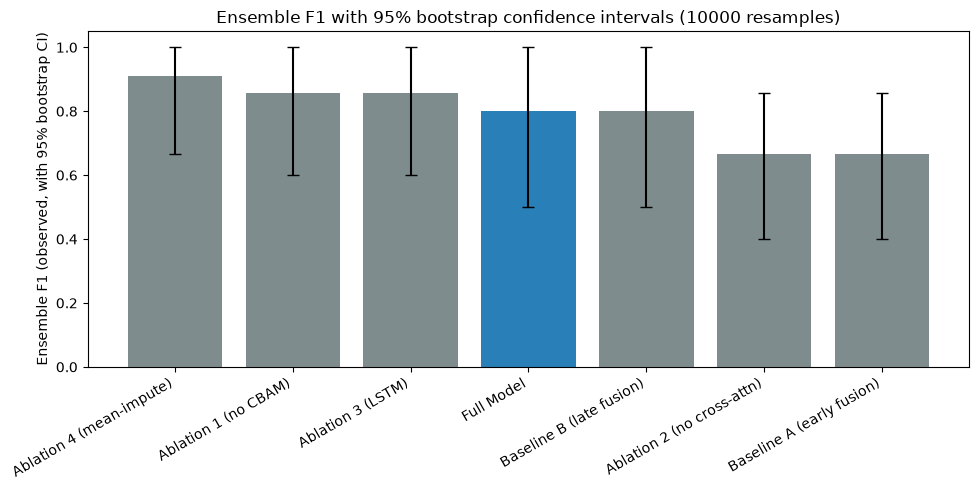

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = f1_ci_df.copy()
x = np.arange(len(plot_df))
colors = ["#2980b9" if k == "full_model" else "#7f8c8d" for k in plot_df["key"]]
yerr = [plot_df["observed_f1"] - plot_df["ci_lower"], plot_df["ci_upper"] - plot_df["observed_f1"]]
ax.bar(x, plot_df["observed_f1"], yerr=yerr, capsize=4, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["config"], rotation=30, ha="right")
ax.set_ylabel("Ensemble F1 (observed, with 95% bootstrap CI)")
ax.set_ylim(0, 1.05)
ax.set_title(f"Ensemble F1 with 95% bootstrap confidence intervals ({N_BOOTSTRAP} resamples)")
plt.tight_layout()
plt.savefig(BOOT_OUT / "fig_f1_with_ci.png", dpi=150)
plt.show()


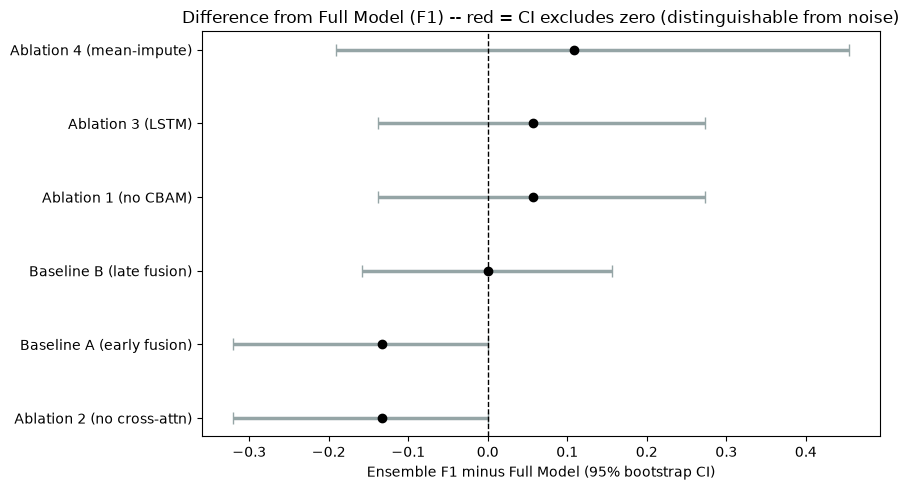

In [34]:
def plot_diff_from_full_model(comparison_df, metric_name, xlabel):
    if comparison_df is None or comparison_df.empty:
        print(f"[SKIP] No comparison data for {metric_name}.")
        return
    fig, ax = plt.subplots(figsize=(9, 5))
    col = f"observed_delta_{metric_name}_vs_full_model"
    plot_df2 = comparison_df.sort_values(col).reset_index(drop=True)
    y = np.arange(len(plot_df2))

    for i, row in plot_df2.iterrows():
        xerr_lo = row[col] - row["ci_lower"]
        xerr_hi = row["ci_upper"] - row[col]
        color = "#c0392b" if row["distinguishable_from_full_model"] else "#95a5a6"
        ax.errorbar([row[col]], [y[i]], xerr=[[xerr_lo], [xerr_hi]], fmt="o", color="black",
                    ecolor=color, elinewidth=2.5, capsize=4)

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df2["config"])
    ax.set_xlabel(xlabel)
    ax.set_title(f"Difference from Full Model ({metric_name.upper()}) -- "
                 f"red = CI excludes zero (distinguishable from noise)")
    plt.tight_layout()
    plt.savefig(BOOT_OUT / f"fig_diff_from_full_model_{metric_name}.png", dpi=150)
    plt.show()


plot_diff_from_full_model(f1_comparison_df, "f1", "Ensemble F1 minus Full Model (95% bootstrap CI)")


## Plots: AUC

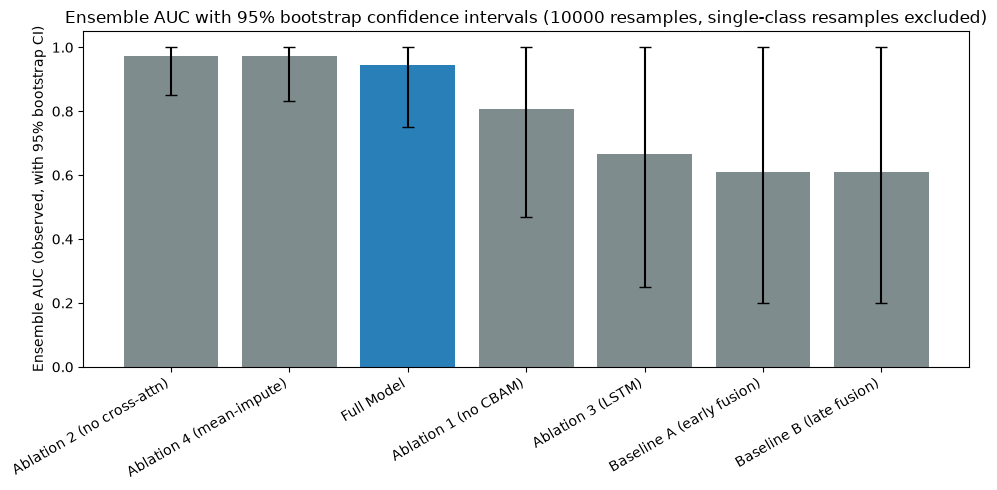

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = auc_ci_df.copy()
x = np.arange(len(plot_df))
colors = ["#2980b9" if k == "full_model" else "#7f8c8d" for k in plot_df["key"]]
yerr = [plot_df["observed_auc"] - plot_df["ci_lower"], plot_df["ci_upper"] - plot_df["observed_auc"]]
ax.bar(x, plot_df["observed_auc"], yerr=yerr, capsize=4, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["config"], rotation=30, ha="right")
ax.set_ylabel("Ensemble AUC (observed, with 95% bootstrap CI)")
ax.set_ylim(0, 1.05)
ax.set_title(f"Ensemble AUC with 95% bootstrap confidence intervals ({N_BOOTSTRAP} resamples, "
             f"single-class resamples excluded)")
plt.tight_layout()
plt.savefig(BOOT_OUT / "fig_auc_with_ci.png", dpi=150)
plt.show()


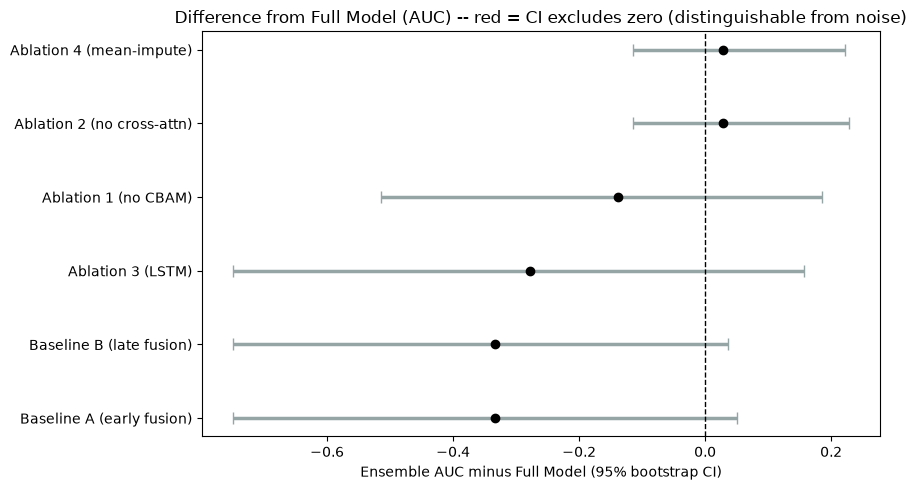

In [36]:
plot_diff_from_full_model(auc_comparison_df, "auc", "Ensemble AUC minus Full Model (95% bootstrap CI)")

## Closing summary: F1 and AUC side by side

In [40]:
def summarize_verdict(comparison_df, metric_name):
    if comparison_df is None or comparison_df.empty:
        print(f"[{metric_name.upper()}] No comparison data.")
        return
    sig = comparison_df[comparison_df["distinguishable_from_full_model"]]
    not_sig = comparison_df[~comparison_df["distinguishable_from_full_model"]]
    col = f"observed_delta_{metric_name}_vs_full_model"

    if sig.empty:
        print(f"[{metric_name.upper()}] Nothing is statistically distinguishable from Full "
              f"Model at 95%")
    else:
        print(f"[{metric_name.upper()}] Distinguishable from Full Model:")
        for _, row in sig.iterrows():
            direction = "better than" if row[col] > 0 else "worse than"
            print(f"    {row['config']}: {direction} Full Model, delta={row[col]:+.4f}, "
                  f"p~{row['p_value_approx']:.4f}")
    if not not_sig.empty:
        print(f"[{metric_name.upper()}] NOT distinguishable from Full Model (consistent with noise):")
        for _, row in not_sig.iterrows():
            print(f"    {row['config']}: delta={row[col]:+.4f}, p~{row['p_value_approx']:.4f}")

if "full_model" not in BOOT_F1:
    print("Full Model has no usable data -- see FAILURES above.")
else:
    print(f"\nFull Model: observed ensemble F1 = {CONFIG_OBSERVED_F1['full_model']:.4f}, "
          f"observed ensemble AUC = {CONFIG_OBSERVED_AUC['full_model']:.4f}, "
          f"based on {len(SEEDS_FOUND['full_model'])} seeds.\n")

    summarize_verdict(f1_comparison_df, "f1")
    print()
    summarize_verdict(auc_comparison_df, "auc")

    both_configs_sig_on_either = set()
    if f1_comparison_df is not None:
        both_configs_sig_on_either |= set(f1_comparison_df[f1_comparison_df["distinguishable_from_full_model"]]["key"])
    if auc_comparison_df is not None:
        both_configs_sig_on_either |= set(auc_comparison_df[auc_comparison_df["distinguishable_from_full_model"]]["key"])

print(f"\nFull results: {BOOT_OUT}")


Full Model: observed ensemble F1 = 0.8000, observed ensemble AUC = 0.9444, based on 10 seeds.

[F1] Nothing is statistically distinguishable from Full Model at 95%
[F1] NOT distinguishable from Full Model (consistent with noise):
    Ablation 4 (mean-impute): delta=+0.1091, p~0.5138
    Ablation 1 (no CBAM): delta=+0.0571, p~0.7660
    Ablation 3 (LSTM): delta=+0.0571, p~0.7660
    Baseline B (late fusion): delta=+0.0000, p~1.0000
    Ablation 2 (no cross-attn): delta=-0.1333, p~0.0636
    Baseline A (early fusion): delta=-0.1333, p~0.0636

[AUC] Nothing is statistically distinguishable from Full Model at 95%
[AUC] NOT distinguishable from Full Model (consistent with noise):
    Ablation 2 (no cross-attn): delta=+0.0278, p~1.0000
    Ablation 4 (mean-impute): delta=+0.0278, p~1.0000
    Ablation 1 (no CBAM): delta=-0.1389, p~0.5051
    Ablation 3 (LSTM): delta=-0.2778, p~0.2976
    Baseline A (early fusion): delta=-0.3333, p~0.1849
    Baseline B (late fusion): delta=-0.3333, p~0.1867